### Import Libraries

In [1]:
import os
import random
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models.segmentation import deeplabv3_resnet50

### Parameters

In [2]:
''' Define parameters.

    NUM_WORKERS: defines how many process CPU will run concurrently in parallel 
    to efficiently preprocess data before feeding into training process of GPU

    THRESH: DeepLabV3 give output as logits -> probabilities. but we basically want 0/1
    classification therefore use THRESH as a cut off threshold.
'''

RAW_DIR   = r"../FishEmbryo_All_Images/FishEmbryo_Raw_Images_Yolk/Yolk"      
LABEL_DIR = r"../FishEmbryo_All_Images/FishEmbryo_Label_Images_BMP/Yolk"    

IMG_SIZE = (512, 512)
BATCH_SIZE = 4
EPOCHS = 20
LR = 1e-4
# WEIGHT_DECAY = 1e-4

# USE_SPLIT = False
# TEST_RATIO = 0.2

THRESH = 0.5

NUM_WORKERS = 2

In [3]:
def sorted_file_list(folder, ext=".bmp"):
    """ Retrieves and sorts image files from a specified folder.
    glob("ext"): find files that match pattern match "ext".
    
    Parameters:
        folder (str or Path): Path to the directory containing the image files.
        ext (str): File extension to filter the files (default is ".bmp").

    Returns:
        list of Path: A sorted list of file paths that match the specified extension.
    """
    folder = Path(folder)
    files = sorted(folder.glob(f"*{ext}"))
    return files

### Class for pairing dataset 

In [4]:
class YolkDataset(Dataset):
    ''' Class for Dataset

    
    '''
    def __init__(self, raw_dir, label_dir, img_size=(512, 512)):
        self.raw_paths = sorted_file_list(raw_dir, ext=".bmp")
        self.label_paths = sorted_file_list(label_dir, ext=".bmp")

        if len(self.raw_paths) == 0:
            raise RuntimeError(f"No raw BMP images found in: {raw_dir}")
        if len(self.label_paths) == 0:
            raise RuntimeError(f"No label BMP images found in: {label_dir}")

        if len(self.raw_paths) != len(self.label_paths):
            print(f"[WARN] raw count = {len(self.raw_paths)}, label count = {len(self.label_paths)}")

        n = min(len(self.raw_paths), len(self.label_paths))
        self.raw_paths = self.raw_paths[:n]
        self.label_paths = self.label_paths[:n]

        print(f"[INFO] Number of paired images: {n}")
        print("[INFO] First 5 sorted pairs:")
        for i in range(min(5, n)):
            print(f"  {self.raw_paths[i].name}  <->  {self.label_paths[i].name}")

        self.img_transform = transforms.Compose([
            transforms.Resize(img_size, interpolation=InterpolationMode.BILINEAR),
            transforms.ToTensor(),  # [0,1]
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]
            ),
        ])

        self.mask_resize = transforms.Resize(img_size, interpolation=InterpolationMode.NEAREST)

    def __len__(self):
        return len(self.raw_paths)

    def __getitem__(self, idx):
        img_path = self.raw_paths[idx]
        mask_path = self.label_paths[idx]

        img = Image.open(img_path).convert("RGB")
        x = self.img_transform(img)

        mask = Image.open(mask_path).convert("L")
        mask = self.mask_resize(mask)
        mask = np.array(mask)

        mask = (mask > 0).astype(np.float32)
        y = torch.from_numpy(mask).unsqueeze(0)   # [1,H,W]

        return x, y, str(img_path), str(mask_path)

In [5]:
def build_model():
    """ Builds and returns a DeepLabV3 model.
    
    Parameters:
        None

    Returns:
        torch.nn.Module: A DeepLabV3 model with a ResNet50 backbone where the
        final classifier layer is modified to output a single channel for
        binary segmentation (yolk vs background).
    """
    model = deeplabv3_resnet50(weights="DEFAULT")
    model.classifier[-1] = nn.Conv2d(256, 1, kernel_size=1)
    return model

In [6]:
def batch_iou(pred, target, eps=1e-7):
    """ Calculates the Intersection over Union (IoU) score for a batch of predicted masks and target masks.
    
    Parameters:
        pred (torch.Tensor): The predicted binary segmentation masks.
        target (torch.Tensor): The ground truth binary segmentation masks.
        eps (float): A small value added to the denominator to avoid division by zero.

    Returns:
        torch.Tensor: The IoU score for each image in the batch.
    """
    pred = pred.bool()
    target = target.bool()

    inter = (pred & target).flatten(1).sum(dim=1).float()
    union = (pred | target).flatten(1).sum(dim=1).float()

    return (inter + eps) / (union + eps)


@torch.no_grad()
def evaluate_iou(model, loader, device, thresh=0.5):
    """ Evaluates the model by computing the mean Intersection over Union (IoU)
    across all images in given loader.
    
    Parameters:
        model (torch.nn.Module): The trained model used for prediction.
        loader (torch.utils.data.DataLoader): DataLoader providing batches of input images
            and corresponding ground-truth masks (label).
        device (torch.device): The device (CPU or GPU) where the model and data are processed.
        thresh (float): The probability threshold used to convert predicted probabilities
            into binary segmentation masks.

    Returns:
        float: The mean IoU score computed over all images in the dataset.
    """
    model.eval()
    all_ious = []

    for x, y, _, _ in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)["out"]
        probs = torch.sigmoid(logits)
        pred = (probs >= thresh).float()

        iou = batch_iou(pred, y)
        all_ious.append(iou.cpu())

    return float(torch.cat(all_ious).mean().item())

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    """ Trains the model for one epoch using batches of training data.
    
    Parameters:
        model (torch.nn.Module): The neural network model to be trained.
        loader (torch.utils.data.DataLoader): DataLoader providing batches of input images
            and corresponding ground-truth masks (label).
        optimizer (torch.optim.Optimizer): The optimization algorithm used to update
            the model parameters.
        criterion (torch.nn.Module): The loss function used to measure prediction error.
        device (torch.device): The device (CPU or GPU) where the model and data are processed.
        scaler (torch.cuda.amp.GradScaler, optional): Gradient scaler used for mixed precision
            training when running on GPU. mainly used incase floating point 16bits is used to
            to prevent very small gradient to become zero.

    Returns:
        float: The average training loss over the entire dataset for the epoch.
    """
    model.train()
    running_loss = 0.0

    for x, y, _, _ in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(x)["out"]
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)["out"]
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)

In [18]:
def main():
    # set_seed(SEED)

    if not os.path.isdir(RAW_DIR):
        raise FileNotFoundError(f"RAW_DIR not found: {RAW_DIR}")
    if not os.path.isdir(LABEL_DIR):
        raise FileNotFoundError(f"LABEL_DIR not found: {LABEL_DIR}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("[INFO] Device:", device)

    ds = YolkDataset(RAW_DIR, LABEL_DIR, img_size=IMG_SIZE)
    train_losses = []
    ious = []

    """ In case there are enough data and want to split train/test dataset
    
    if USE_SPLIT:
        test_len = int(round(len(ds) * TEST_RATIO))
        train_len = len(ds) - test_len
        train_ds, test_ds = random_split(
            ds,
            [train_len, test_len],
            generator=torch.Generator().manual_seed(SEED)
        )

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True)
        eval_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=True)
        print(f"[INFO] Split: train={train_len}, test={test_len}")
    else:
    """
    train_loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True)
    eval_loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=True)
    print("[INFO] Training on ALL images")
    

    model = build_model().to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None

    # best_iou = -1.0    # in case wanna save best model

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler)
        mean_iou = evaluate_iou(model, eval_loader, device, thresh=THRESH)

        train_losses.append(train_loss)
        ious.append(mean_iou)

        """ in case wanna save best model
        if mean_iou > best_iou:
            best_iou = mean_iou
            torch.save(model.state_dict(), "best_deeplabv3_yolk_professor_style.pth")
        """
        
        print(f"Epoch {epoch:02d}/{EPOCHS} | loss={train_loss:.4f} | mean IoU={mean_iou:.4f}")

    """ in case wanna save best model
    print(f"\n[RESULT] Best mean IoU = {best_iou:.4f}")
    print("[INFO] Saved model: best_deeplabv3_yolk_professor_style.pth")

    model.load_state_dict(torch.load("best_deeplabv3_yolk_professor_style.pth", map_location=device))
    """
    final_iou = evaluate_iou(model, eval_loader, device, thresh=THRESH)
    print(f"Mean IoU = {final_iou:.4f}")
    return model, train_losses, ious

In [19]:
if __name__ == "__main__":
    model, train_losses, ious = main()

[INFO] Device: cuda
[INFO] Number of paired images: 74
[INFO] First 5 sorted pairs:
  Img1Z 03_006--L06_NA_Acetaminophen_0.bmp  <->  Img1Z 03_006--L06_Yolk_Acetaminophen_0.bmp
  Img1Z 03_006--L12_NA_Acetaminophen_0.bmp  <->  Img1Z 03_006--L12_Yolk_Acetaminophen_0.bmp
  Img1Z 03_006--L18_NA_Acetaminophen_0.bmp  <->  Img1Z 03_006--L18_Yolk_Acetaminophen_0.bmp
  Img1Z 03_007--L02_NA_Acetaminophen_3.75.bmp  <->  Img1Z 03_007--L02_Yolk_Acetaminophen_3.75.bmp
  Img1Z 03_007--L03_NA_Acetaminophen_0.bmp  <->  Img1Z 03_007--L03_Yolk_Acetaminophen_0.bmp
[INFO] Training on ALL images
Epoch 01/20 | loss=0.5438 | mean IoU=0.6458
Epoch 02/20 | loss=0.3220 | mean IoU=0.7747
Epoch 03/20 | loss=0.2643 | mean IoU=0.8423
Epoch 04/20 | loss=0.2347 | mean IoU=0.8717
Epoch 05/20 | loss=0.2124 | mean IoU=0.8974
Epoch 06/20 | loss=0.1944 | mean IoU=0.8983
Epoch 07/20 | loss=0.1782 | mean IoU=0.9041
Epoch 08/20 | loss=0.1642 | mean IoU=0.9055
Epoch 09/20 | loss=0.1516 | mean IoU=0.9298
Epoch 10/20 | loss=0.140

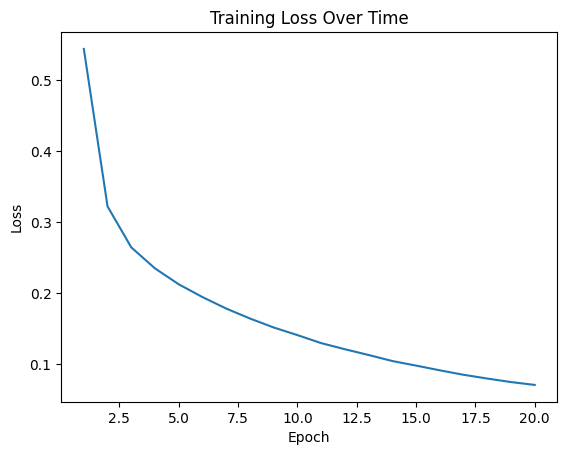

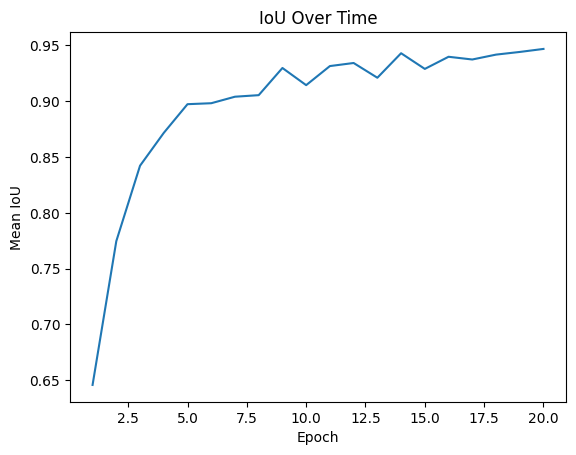

In [21]:
epochs = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epochs, train_losses)
plt.title("Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(epochs, ious)
plt.title("IoU Over Time")
plt.xlabel("Epoch")
plt.ylabel("Mean IoU")
plt.show()

[INFO] Number of paired images: 74
[INFO] First 5 sorted pairs:
  Img1Z 03_006--L06_NA_Acetaminophen_0.bmp  <->  Img1Z 03_006--L06_Yolk_Acetaminophen_0.bmp
  Img1Z 03_006--L12_NA_Acetaminophen_0.bmp  <->  Img1Z 03_006--L12_Yolk_Acetaminophen_0.bmp
  Img1Z 03_006--L18_NA_Acetaminophen_0.bmp  <->  Img1Z 03_006--L18_Yolk_Acetaminophen_0.bmp
  Img1Z 03_007--L02_NA_Acetaminophen_3.75.bmp  <->  Img1Z 03_007--L02_Yolk_Acetaminophen_3.75.bmp
  Img1Z 03_007--L03_NA_Acetaminophen_0.bmp  <->  Img1Z 03_007--L03_Yolk_Acetaminophen_0.bmp


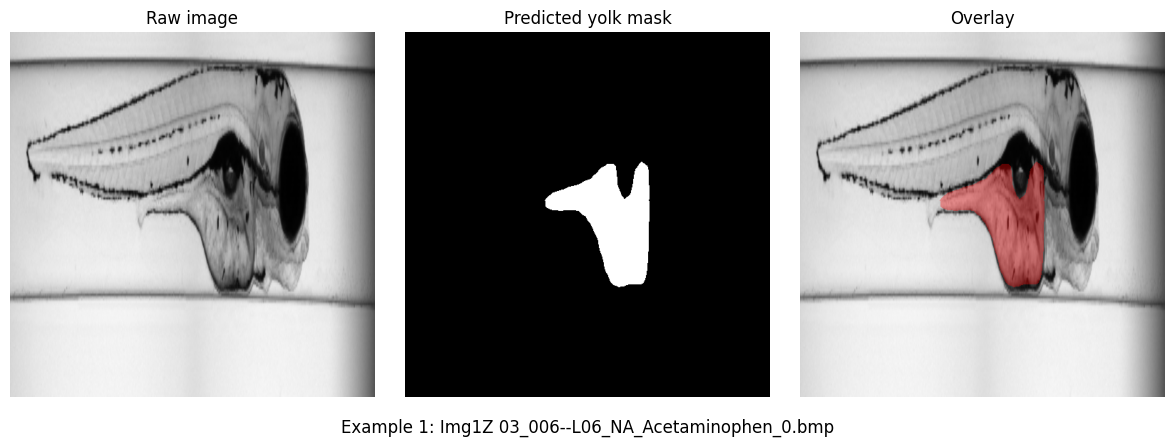

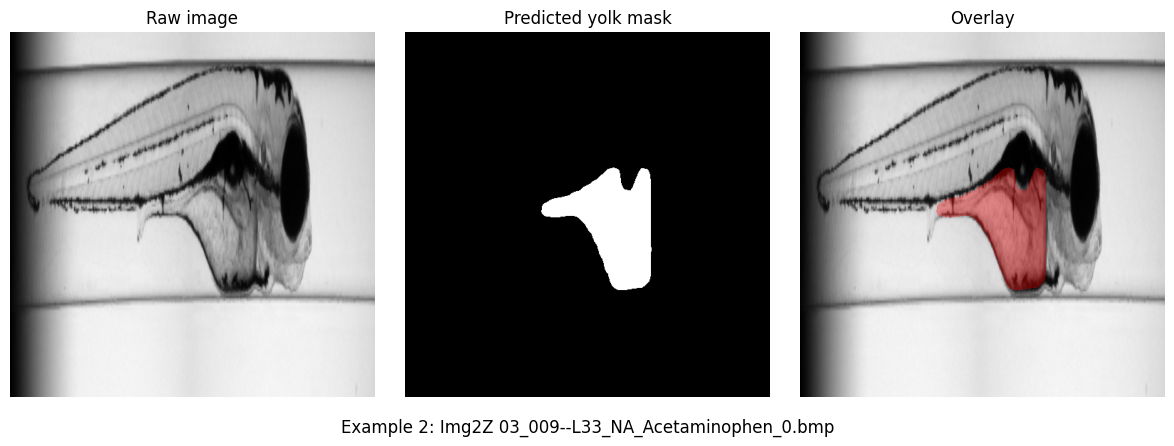

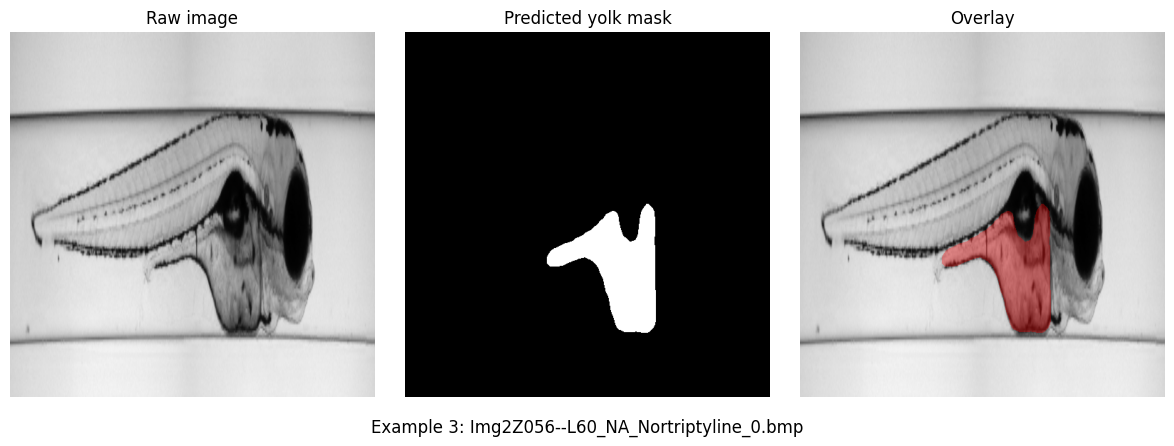

In [25]:
model.eval()
ds = YolkDataset(RAW_DIR, LABEL_DIR, img_size=IMG_SIZE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
thresh = 0.5

if len(ds) >= 3:
    idxs = [0, len(ds)//2, len(ds)-1]
else:
    idxs = list(range(len(ds)))

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

with torch.no_grad():

    for i, idx in enumerate(idxs[:3]):
        x, y, img_path, mask_path = ds[idx]

        x_in = x.unsqueeze(0).to(device)

        logits = model(x_in)["out"][0, 0]
        prob = torch.sigmoid(logits).cpu().numpy()
        pred = (prob >= thresh).astype(np.uint8)

        # De-normalize image
        img_np = x.cpu().numpy().transpose(1, 2, 0)
        img_np = (img_np * std + mean).clip(0, 1)

        # Overlay prediction in red
        overlay = img_np.copy()
        alpha = 0.35
        red = np.zeros_like(overlay)
        red[..., 0] = 1.0

        overlay = np.where(
            pred[..., None] == 1,
            (1 - alpha) * overlay + alpha * red,
            overlay
        )

        plt.figure(figsize=(12,4))
        

        plt.subplot(1,3,1)
        plt.title("Raw image")
        plt.imshow(img_np)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Predicted yolk mask")
        plt.imshow(pred, cmap="gray")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("Overlay")
        plt.imshow(overlay)
        plt.axis("off")

        plt.tight_layout()
        plt.figtext(0.5, -0.05, f"Example {i+1}: {Path(img_path).name}", ha="center", fontsize=12)
        plt.show()